# EDA - Credit Score

Business Problem:

> "Will this customer default on their credit line in the next 2 years?"

This is purely exploratory. No transforms, no writes.

- How severe is the class imbalance? (determines scale_pos_weight value for XGBoost)
- Which features have outliers so extreme they're data errors vs. legitimate? (determines capping thresholds)
- Is missingness in monthly_income random or correlated with default? (determines imputation strategy)
- Are there any features with near-zero variance or perfect correlation? (determines if we drop anything)


Install packages

In [1]:
# !uv pip install -q \
#         pandas==3.0.1 \
#         pyarrow==23.0.1 \
#         boto3==1.42.68 \
#         matplotlib==3.10.8 \
#         seaborn==0.13.2 \
#         scipy==1.17.1

Check package versions

In [2]:
!uv pip freeze | grep -E "pandas|pyarrow|boto3|matplotlib|seaborn|scipy"

boto3==1.42.68
matplotlib==3.10.8
pandas==3.0.1
pyarrow==23.0.1
scipy==1.17.1
seaborn==0.13.2


Import packages

In [3]:
import io
import warnings

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [4]:
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.expand_frame_repr", False)

sns.set_style("darkgrid")
sns.set_theme(style="darkgrid")

S3_ENDPOINT = "http://localstack:4566"
BUCKET = "data-lake"
PREFIX = "silver/credit_risk/cleaned/ingestion_date=2026-03-14/"

Load Dataset

In [5]:
s3_client = boto3.client(
    "s3",
)


response = s3_client.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX)
parquet_keys = [
    obj["Key"]
    for obj in response.get("Contents", [])
    if obj["Key"].endswith(".parquet")
]


dfs = []

for key in parquet_keys:
    obj = s3_client.get_object(Bucket=BUCKET, Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(obj["Body"].read())))

df = pd.concat(dfs, ignore_index=True)

df.head()

,serious_dlqin2yrs,revolving_utilization_of_unsecured_lines,age,number_of_time30_59_days_past_due_not_worse,debt_ratio,monthly_income,number_of_open_credit_lines_and_loans,number_of_times90_days_late,number_real_estate_loans_or_lines,number_of_time60_89_days_past_due_not_worse,number_of_dependents
0,1,0.8804,43,0,0.4613,7523.0000,6,0,1,0,1.0000
1,0,0.0224,72,0,1004.0000,NaN,6,0,1,0,0.0000
2,0,0.5589,49,0,0.4871,9077.0000,18,0,1,0,3.0000
3,0,0.1458,61,0,1211.0000,NaN,8,0,1,0,0.0000
4,0,0.2074,54,0,0.3909,8685.0000,11,0,1,0,2.0000


Define target & features

In [6]:
df = df.drop(columns=["ingestion_date"], errors="ignore")

TARGET = "serious_dlqin2yrs"
FEATURES = [c for c in df.columns if c != TARGET]

In [7]:
print(f"Shape: {df.shape}\n")
print(f"\nTarget: {TARGET}\n")
print(f"Features: {FEATURES}\n")

Shape: (149391, 11)


Target: serious_dlqin2yrs

Features: ['revolving_utilization_of_unsecured_lines', 'age', 'number_of_time30_59_days_past_due_not_worse', 'debt_ratio', 'monthly_income', 'number_of_open_credit_lines_and_loans', 'number_of_times90_days_late', 'number_real_estate_loans_or_lines', 'number_of_time60_89_days_past_due_not_worse', 'number_of_dependents']



## Target distribution

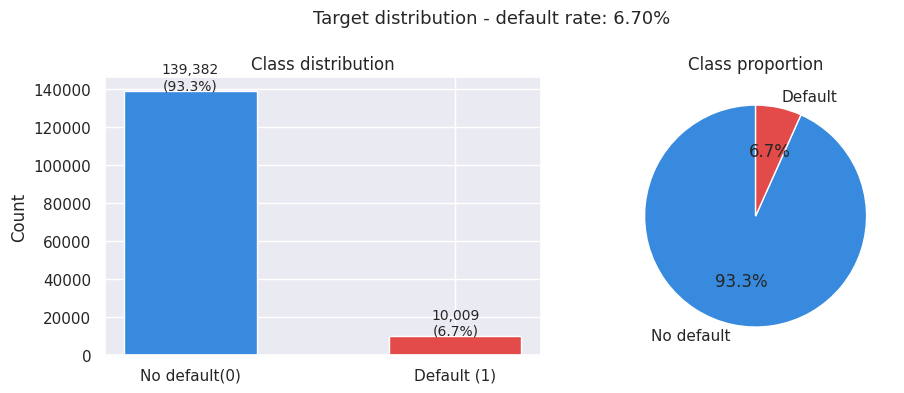


Imbalance Ratio (neg/pos): 13.93
Use scale_pos_weight=13.9 for XGBoost/LightGBM


In [8]:
counts = df[TARGET].value_counts()

rate = counts[1] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    ["No default(0)", "Default (1)"],
    counts.values,
    color=["#378ADD", "#E24B4A"],
    width=0.5,
)
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")

label_margin_offset = 500

for index, value in enumerate(counts.values):
    axes[0].text(
        index,
        value + label_margin_offset,
        f"{value:,}\n({value/len(df)*100:.1f}%)",
        ha="center",
        fontsize=10,
    )

axes[1].pie(
    counts.values,
    labels=["No default", "Default"],
    autopct="%1.1f%%",
    colors=["#378ADD", "#E24B4A"],
    startangle=90,
)
axes[1].set_title("Class proportion")


plt.suptitle(f"Target distribution - default rate: {rate:.2f}%", fontsize=13)
plt.tight_layout()


plt.show()

scale_pos_weight = counts[0] / counts[1]
print(f"\nImbalance Ratio (neg/pos): {scale_pos_weight:.2f}")
print(f"Use scale_pos_weight={scale_pos_weight:.1f} for XGBoost/LightGBM")

## Missingness audit

In [27]:
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)

print("=== Missing values ===")
for col in miss.index:
    print(f" {col:<45} {miss[col]:>6} ({miss_pct[col]:.2f}%)")

print("\n=== Is missingness correlated to default? ===")
for col in miss.index:
    mask = df[col].isnull()
    default_missing = df.loc[mask, TARGET].mean()
    default_present = df.loc[~mask, TARGET].mean()
    print(f" {col}")
    print(f"  default rate when MISSING: {default_missing:.4f}")
    print(f"  default rate when PRESENT: {default_present:.4f}")
    print(f"""
        => {
        'INFORMATIVE missingness — consider missing indicator feature'
        if abs(default_missing - default_present) > 0.01
        else 'likely MCAR — simple median imputation is fine'}
        """)

=== Missing values ===
 monthly_income                                 29221 (19.56%)
 number_of_dependents                            3828 (2.56%)

=== Is missingness correlated to default? ===
 monthly_income
  default rate when MISSING: 0.0566
  default rate when PRESENT: 0.0695

        => INFORMATIVE missingness — consider missing indicator feature
        
 number_of_dependents
  default rate when MISSING: 0.0465
  default rate when PRESENT: 0.0675

        => INFORMATIVE missingness — consider missing indicator feature
        


## Feature distribution & outlier audit

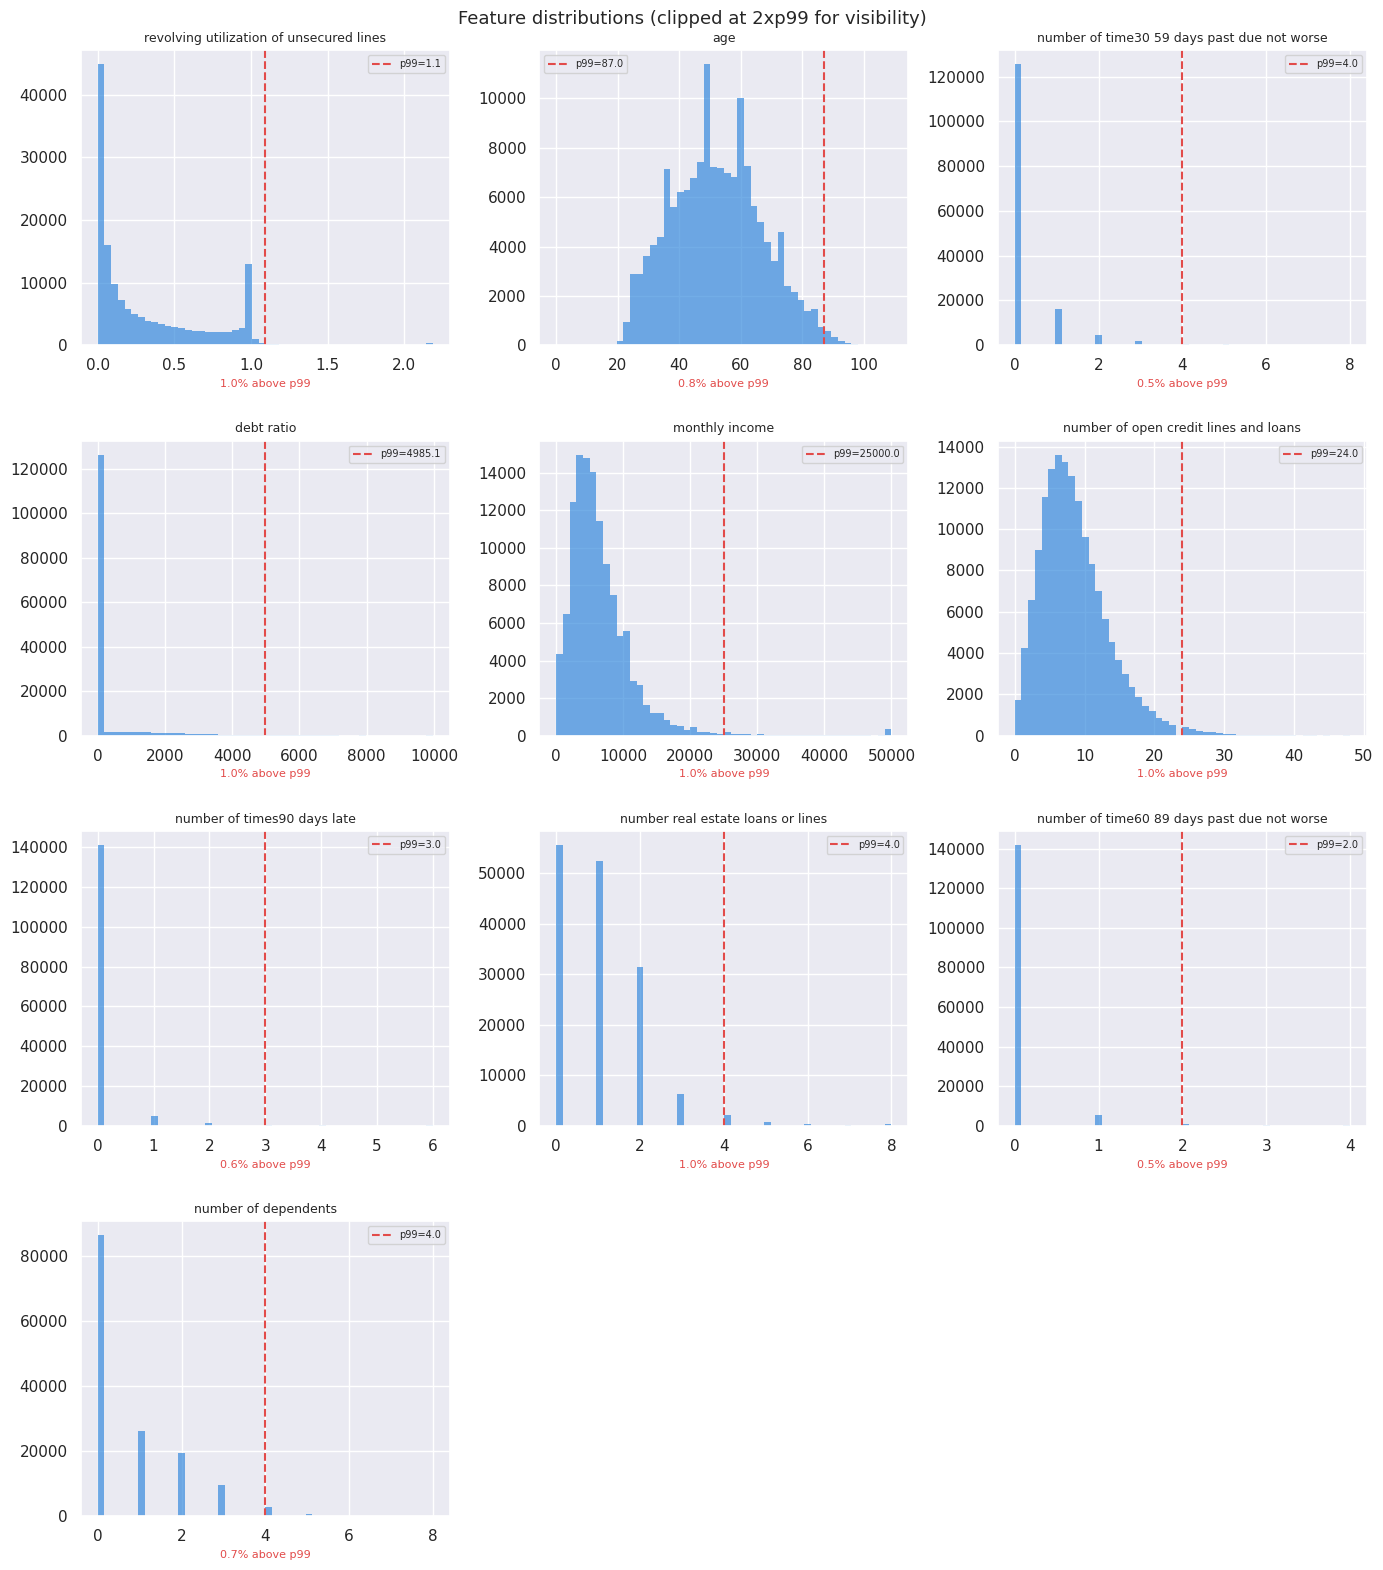


=== Outlier Summary (Values above p99) ===
                                                 1%        99%          max  % > p99
revolving_utilization_of_unsecured_lines     0.0000     1.0900   50708.0000   1.0000
age                                         24.0000    87.0000     109.0000   0.8400
number_of_time30_59_days_past_due_not_worse  0.0000     4.0000      98.0000   0.5400
debt_ratio                                   0.0000  4985.1000  329664.0000   1.0000
monthly_income                               0.0000 25000.0000 3008750.0000   0.7800
number_of_open_credit_lines_and_loans        0.0000    24.0000      58.0000   0.9900
number_of_times90_days_late                  0.0000     3.0000      98.0000   0.5500
number_real_estate_loans_or_lines            0.0000     4.0000      54.0000   0.9900
number_of_time60_89_days_past_due_not_worse  0.0000     2.0000      98.0000   0.4800
number_of_dependents                         0.0000     4.0000      20.0000   0.6600


In [29]:
fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.flatten()

for index, col in enumerate(FEATURES):
    ax = axes[index]
    data = df[col].dropna()
    p1, p99 = data.quantile(0.01), data.quantile(0.99)

    ax.hist(
        data.clip(upper=p99 * 2),
        bins=50,
        color="#378ADD",
        alpha=0.7,
        edgecolor="none",
    )
    ax.axvline(
        p99,
        color="#E24B4A",
        linewidth=1.5,
        linestyle="--",
        label=f"p99={p99:.1f}",
    )
    ax.set_title(col.replace("_", " "), fontsize=9)
    ax.legend(fontsize=7)

    extreme_pct = (data > p99).sum() / len(data) * 100
    if extreme_pct > 0:
        ax.set_xlabel(
            f"{extreme_pct:.1f}% above p99",
            fontsize=8,
            color="#E24B4A",
        )

for j in range(index + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions (clipped at 2xp99 for visibility)", fontsize=13)
plt.tight_layout(h_pad=2.0)
plt.show()

summary = df[FEATURES].describe(percentiles=[0.01, 0.99]).T
summary["% > p99"] = (df[FEATURES] > summary["99%"]).mean() * 100

print("\n=== Outlier Summary (Values above p99) ===")
print(summary[["1%", "99%", "max", "% > p99"]].round(2))

## Correlation Matix

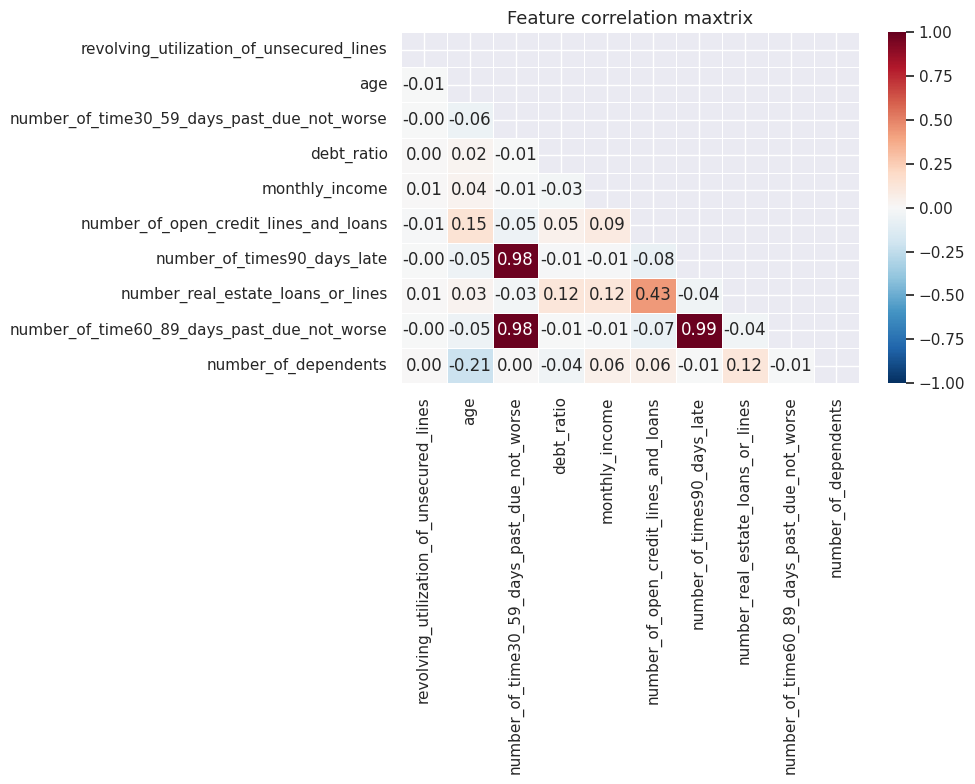


=== High correlations ===
 number_of_time30_59_days_past_due_not_worse ==>
 number_of_times90_days_late: 0.980
 number_of_time30_59_days_past_due_not_worse ==>
 number_of_time60_89_days_past_due_not_worse: 0.985
 number_of_times90_days_late ==>
 number_of_time60_89_days_past_due_not_worse: 0.991


In [20]:
corr = df[FEATURES].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)

ax.set_title("Feature correlation maxtrix", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== High correlations ===")
for index in range(len(corr.columns)):
    for j in range(index + 1, len(corr.columns)):
        r = corr.iloc[index, j]
        if abs(r) > 0.5:
            print(f" {corr.columns[index]} ==>\n {corr.columns[j]}: {r:.3f}")

## Feature vs. target

Each chart cuts one feature into 10 buckets (deciles) from lowest values to highest, then shows the default rate % inside each bucket. It's the most intuitive way to see if a feature actually predicts default.

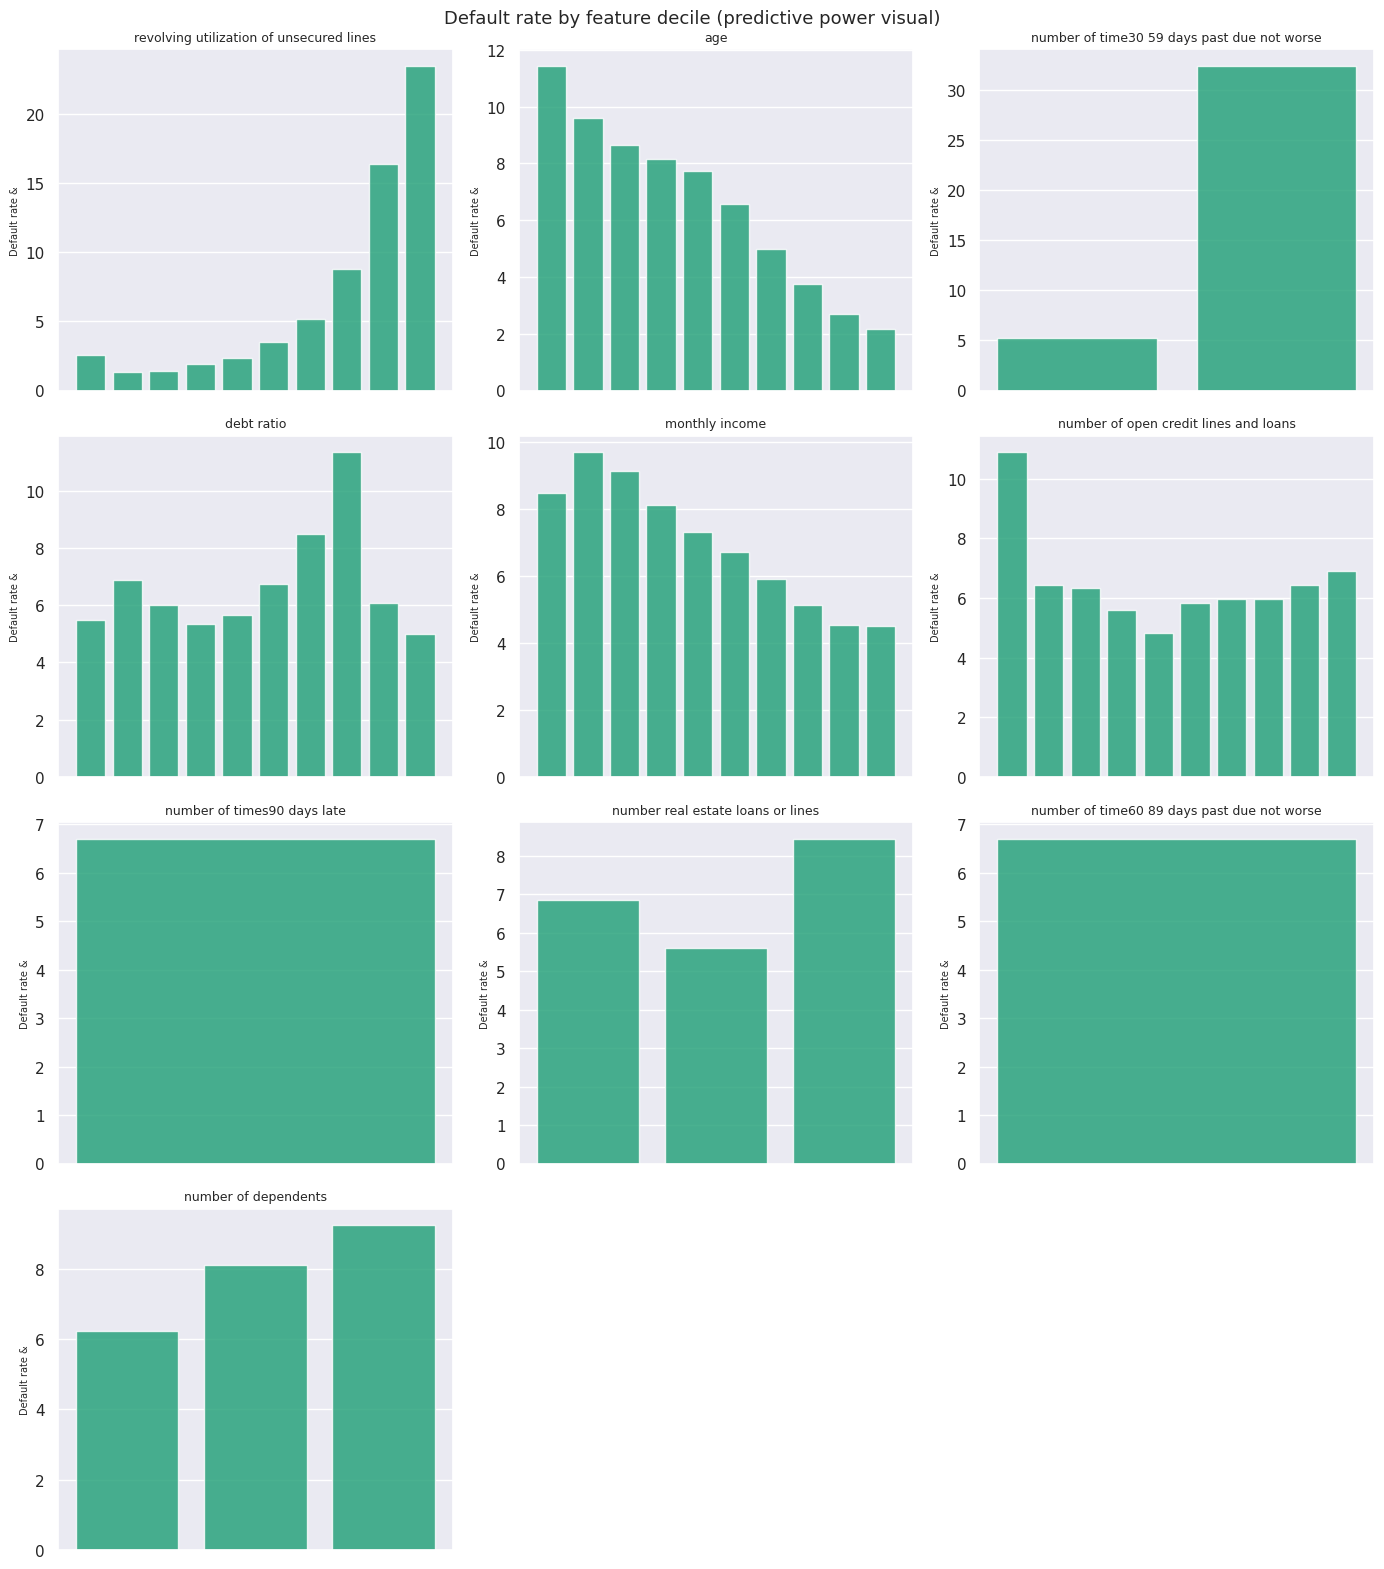

In [23]:
fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.flatten()

for index, col in enumerate(FEATURES):
    ax = axes[index]
    temp = df[[col, TARGET]].copy().dropna()
    temp["decile"] = pd.qcut(
        temp[col].clip(upper=temp[col].quantile(0.99)),
        q=10,
        duplicates="drop",
    )
    rate_by_decile = temp.groupby("decile", observed=True)[TARGET].mean() * 100

    ax.bar(
        range(len(rate_by_decile)),
        rate_by_decile.values,
        color="#1D9E75",
        alpha=0.8,
    )
    ax.set_title(col.replace("_", " "), fontsize=9)
    ax.set_ylabel("Default rate &", fontsize=7)
    ax.set_xticks([])

for j in range(index + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Default rate by feature decile (predictive power visual)", fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
print("=" * 65)
print("EDA DECISIONS LOG")
print("=" * 65)

imbalance = df[TARGET].value_counts()
print(f"\n[IMBALANCE]")
print(f"  Default rate: {imbalance[1]/len(df)*100:.2f}%")
print(f"  scale_pos_weight for XGBoost/LightGBM: {imbalance[0]/imbalance[1]:.1f}")

print(f"\n[MISSINGNESS]")
for col in df.columns:
    pct = df[col].isnull().mean() * 100
    if pct > 0:
        print(f"  {col}: {pct:.2f}% missing → median imputation")

print(f"\n[OUTLIER CAPPING — fit on train only]")
for col in FEATURES:
    data = df[col].dropna()
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    extreme = (data > p99).sum() / len(data) * 100
    if extreme > 1.0:
        print(f"  {col}: cap at p99={p99:.2f} ({extreme:.1f}% affected)")

print(f"\n[FEATURES TO WATCH]")
print(f"  age: check for 0 values (data error)")
print(f"  revolving_utilization: values >> 1.0 are data errors, cap at 1.0")
print(f"  debt_ratio: extremely high values likely erroneous")

EDA DECISIONS LOG

[IMBALANCE]
  Default rate: 6.70%
  scale_pos_weight for XGBoost/LightGBM: 13.9

[MISSINGNESS]
  monthly_income: 19.56% missing → median imputation
  number_of_dependents: 2.56% missing → median imputation

[OUTLIER CAPPING — fit on train only]
  revolving_utilization_of_unsecured_lines: cap at p99=1.09 (1.0% affected)
  debt_ratio: cap at p99=4985.10 (1.0% affected)

[FEATURES TO WATCH]
  age: check for 0 values (data error)
  revolving_utilization: values >> 1.0 are data errors, cap at 1.0
  debt_ratio: extremely high values likely erroneous


## Summary

### Imbalance

- confirmed scale_pos_weight=13.9 for XGBoost/LightGBM
- For Logistic Regression we use class_weight='balanced'
- **NOT use SMOTE**: at this imbalance ratio SMOTE creates too many synthetic positives and tends to hurt AUC on real credit data
- Threshold tuning at evaluation time will be more effective.

### Missingness

- both features are **INFORMATIVE**
- People with missing monthly_income default at 5.66% vs 6.95% for those who reported it
- Missing income correlates with lower default. This could mean: self-employed / informal workers don't have a payslip (lower risk profile in this dataset), or wealthier people didn't bother filling it
- Add monthly_income_is_missing and number_of_dependents_is_missing as binary features. This is a feature engineering decision, not a preprocessing decision — the indicator gets created before imputation.

### Outliers

- `revolving_utilization` max = 50,708, this is a data error, not an extreme borrower. A utilization of 50,000% is physically impossible. Cap hard at 1.0 (100% utilization is the legitimate maximum). The p99 is already 1.09 which confirms this
- `debt_ratio` max = 329,664 — same situation. A debt ratio of 300,000 means debt is 300,000× income, which is nonsensical. Cap at p99 = 4,985, but we'll also explore capping more aggressively at a business-logic ceiling (e.g., 10 or 20)
- `age` max = 109 — plausible but suspicious. We need to check for age = 0 values specifically (a known issue in this dataset). p1 = 24 is fine
- Delinquency features (`30-59`, `60-89`, `90` days) max = 98 — this is a known sentinel value in this dataset. 98 means "98 or more times" and is used as a cap by the original data provider. It's legitimate, not an error. But the values 96, 98 cluster suspiciously — they're coded values, not real counts. We cap at p99 which handles this cleanly

### Correlations

- **High correlations** (0.98–0.99 between the three delinquency features), this is multicollinearity:
    - For Logistic Regression this is a real problem (unstable coefficients)
    - For tree models (XGBoost, LightGBM, CatBoost, RandomForest) it's irrelevant, they select features independently at each split
    - keep all three for tree models. For LogReg, we'll create a single composite delinquency score in (total_delinquency_score = 30_59 + 60_89*2 + 90_late*3) to collapse the correlation

**Multicollinearity** occurs when two or more predictor variables in a statistical model are highly correlated, meaning one can be linearly predicted from the others with a high degree of accuracy. In simpler terms, it means your "independent" variables aren't actually independent; they are providing redundant information.

As consequence **Reduced Statistical Power**: It becomes difficult for the model to "decide" which variable is actually responsible for the effect, leading to large standard errors and making it harder to achieve statistical significance for individual features.

In [31]:
print("=== Age sanity check ===")
print(df["age"].value_counts().sort_index().head(10))
print(f"\nRows with age == 0: {(df['age'] == 0).sum()}")
print(f"Rows with age < 18: {(df['age'] < 18).sum()}")

# Drop age < 18 legally cannot hold credit, data errors
df_clean = df[df["age"] >= 18].copy()
print(f"\nRows dropped (age < 18): {len(df) - len(df_clean)}")
print(f"Remaining: {len(df_clean)}")

=== Age sanity check ===
age
0        1
21     162
22     368
23     592
24     783
25     938
26    1186
27    1330
28    1556
29    1694
Name: count, dtype: int64

Rows with age == 0: 1
Rows with age < 18: 1

Rows dropped (age < 18): 1
Remaining: 149390
